Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.11.13
IPython version      : 7.34.0

torch: 2.6.0+cu124



# GoogLeNet Classifier on CIFAR-10

**Network Architecture:**
<!-- 
![GoogLeNet](https://www.researchgate.net/profile/Pornntiwa-Pawara/publication/314119821/figure/fig1/AS:467059046916097@1488366962933/The-illustration-of-the-GoogleNet-architecture-Szegedy-et-al-2015-All-convolutional.png)

[Source](https://www.researchgate.net/publication/314119821_Comparing_Local_Descriptors_and_Bags_of_Visual_Words_to_Deep_Convolutional_Neural_Networks_for_Plant_Recognition)-->

![GoogLeNet](https://media.licdn.com/dms/image/v2/D4E12AQF7pF-mIf_Q8A/article-inline_image-shrink_400_744/article-inline_image-shrink_400_744/0/1705980403233?e=2147483647&v=beta&t=pymMJUKjcXEysZyvt-yH19sgy4SIo4AdoQ9yLb1yKD8)

[Source](https://www.linkedin.com/pulse/comprehensive-guide-what-convolutional-neural-networks-basicaius-pwoscn)


**REFERENCES:**
1. Szegedy, Christian, et al. ["Going Deeper with Convolutions."](https://arxiv.org/pdf/1409.4842) Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2015. arXiv:1409.4842.
2. Johnson, J. (2022, February 2). _Lecture 8: CNN Architectures_ [PowerPoint Slides]. University of Michigan EECS 498/598: Deep Learning for Computer Vision. pp 67-76. https://web.eecs.umich.edu/~justincj/slides/eecs498/WI2022/598_WI2022_lecture08.pdf
3. Kim, S. (n.d.). _GoogLeNet-Inception_ [Source code]. GitHub. https://github.com/conan7882/GoogLeNet-Inception

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [6]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 
LEARNING_RATE = 0.01
NUM_EPOCHS = 20
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---
# 1. Data Preparation & Loading

---

In [7]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

# CIFAR-10 preprocessing
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   
    transforms.RandomHorizontalFlip(),      
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) 
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [00:01<00:00, 95.5MB/s] 


---
# 2. Model Creation

---

In [8]:
class Inception(nn.Module):
    def __init__(self, in_planes, n1x1, n3x3red, n3x3, n5x5red, n5x5, pool_planes):
        super(Inception, self).__init__()
        # 1x1 conv branch
        self.b1 = nn.Sequential(
            nn.Conv2d(in_planes, n1x1, kernel_size=1),
            nn.BatchNorm2d(n1x1),
            nn.ReLU(True),
        )

        # 1x1 conv -> 3x3 conv branch
        self.b2 = nn.Sequential(
            nn.Conv2d(in_planes, n3x3red, kernel_size=1),
            nn.BatchNorm2d(n3x3red),
            nn.ReLU(True),
            nn.Conv2d(n3x3red, n3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(n3x3),
            nn.ReLU(True),
        )

        # 1x1 conv -> 5x5 conv branch
        self.b3 = nn.Sequential(
            nn.Conv2d(in_planes, n5x5red, kernel_size=1),
            nn.BatchNorm2d(n5x5red),
            nn.ReLU(True),
            nn.Conv2d(n5x5red, n5x5, kernel_size=5, padding=2), # Note: padding=2 keeps size same
            nn.BatchNorm2d(n5x5),
            nn.ReLU(True),
        )
        
        # self.b3 = nn.Sequential(
        #     nn.Conv2d(in_planes, n5x5red, kernel_size=1),
        #     nn.BatchNorm2d(n5x5red),
        #     nn.ReLU(True),
        #     nn.Conv2d(n5x5red, n5x5, kernel_size=3, padding=1), # Paper uses 5x5, but two 3x3 is common
        #     nn.BatchNorm2d(n5x5),
        #     nn.ReLU(True),
        #     nn.Conv2d(n5x5, n5x5, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(n5x5),
        #     nn.ReLU(True),
        # )

        # 3x3 pool -> 1x1 conv branch
        self.b4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_planes, pool_planes, kernel_size=1),
            nn.BatchNorm2d(pool_planes),
            nn.ReLU(True),
        )

    def forward(self, x):
        y1 = self.b1(x)
        y2 = self.b2(x)
        y3 = self.b3(x)
        y4 = self.b4(x)
        return torch.cat([y1, y2, y3, y4], 1)


class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super(GoogLeNet, self).__init__()
        self.pre_layers = nn.Sequential(
            nn.Conv2d(3, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(True),
        )

        self.a3 = Inception(192,  64,  96, 128, 16, 32, 32)
        self.b3 = Inception(256, 128, 128, 192, 32, 96, 64)

        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.a4 = Inception(480, 192,  96, 208, 16,  48,  64)
        self.b4 = Inception(512, 160, 112, 224, 24,  64,  64)
        self.c4 = Inception(512, 128, 128, 256, 24,  64,  64)
        self.d4 = Inception(512, 112, 144, 288, 32,  64,  64)
        self.e4 = Inception(528, 256, 160, 320, 32, 128, 128)

        self.a5 = Inception(832, 256, 160, 320, 32, 128, 128)
        self.b5 = Inception(832, 384, 192, 384, 48, 128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.linear = nn.Linear(1024, num_classes)

    def forward(self, x):
        out = self.pre_layers(x)
        out = self.a3(out)
        out = self.b3(out)
        out = self.maxpool(out)
        out = self.a4(out)
        out = self.b4(out)
        out = self.c4(out)
        out = self.d4(out)
        out = self.e4(out)
        out = self.maxpool(out)
        out = self.a5(out)
        out = self.b5(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.linear(out)
        return out

In [9]:
set_all_seeds(RANDOM_SEED)
model = GoogLeNet(num_classes=NUM_CLASSES).to(device)

# Model parameter details
summary(model, 
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE), # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
GoogLeNet                                [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 192, 32, 32]        --                        --                        --
│    └─Conv2d: 2-1                       [128, 3, 32, 32]          [128, 192, 32, 32]        5,376                     [3, 3]                    704,643,072
│    └─BatchNorm2d: 2-2                  [128, 192, 32, 32]        [128, 192, 32, 32]        384                       --                        49,152
│    └─ReLU: 2-3                         [128, 192, 32, 32]        [128, 192, 32, 32]        --                        --                        --
├─Inception: 1-2                         [128, 192, 32, 32]        [128, 256, 32, 32]       

---
# 3. Model Training, Testing & Evaluation

---

In [12]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)
    
    # scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          f'LR: {current_lr:.8f}'
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/20 | Train Loss: 1.28648, Train Acc.: 66.08% | Val Loss: 1.02909, Val Acc.: 65.24% | LR: 0.01000000
Epoch 2/20 | Train Loss: 0.78526, Train Acc.: 75.45% | Val Loss: 0.78191, Val Acc.: 72.12% | LR: 0.01000000
Epoch 3/20 | Train Loss: 0.59302, Train Acc.: 79.38% | Val Loss: 0.66688, Val Acc.: 77.94% | LR: 0.01000000
Epoch 4/20 | Train Loss: 0.48664, Train Acc.: 81.00% | Val Loss: 0.64376, Val Acc.: 79.00% | LR: 0.01000000
Epoch 5/20 | Train Loss: 0.41288, Train Acc.: 86.28% | Val Loss: 0.50406, Val Acc.: 83.12% | LR: 0.01000000
Epoch 6/20 | Train Loss: 0.35927, Train Acc.: 82.10% | Val Loss: 0.63354, Val Acc.: 78.94% | LR: 0.01000000
Epoch 7/20 | Train Loss: 0.32183, Train Acc.: 88.21% | Val Loss: 0.51100, Val Acc.: 83.24% | LR: 0.01000000
Epoch 8/20 | Train Loss: 0.29152, Train Acc.: 87.65% | Val Loss: 0.53622, Val Acc.: 82.36% | LR: 0.01000000
Epoch 9/20 | Train Loss: 0.25946, Train Acc.: 90.48% | Val Loss: 0.45209, Val Acc.: 85.66% | LR: 0.01000000

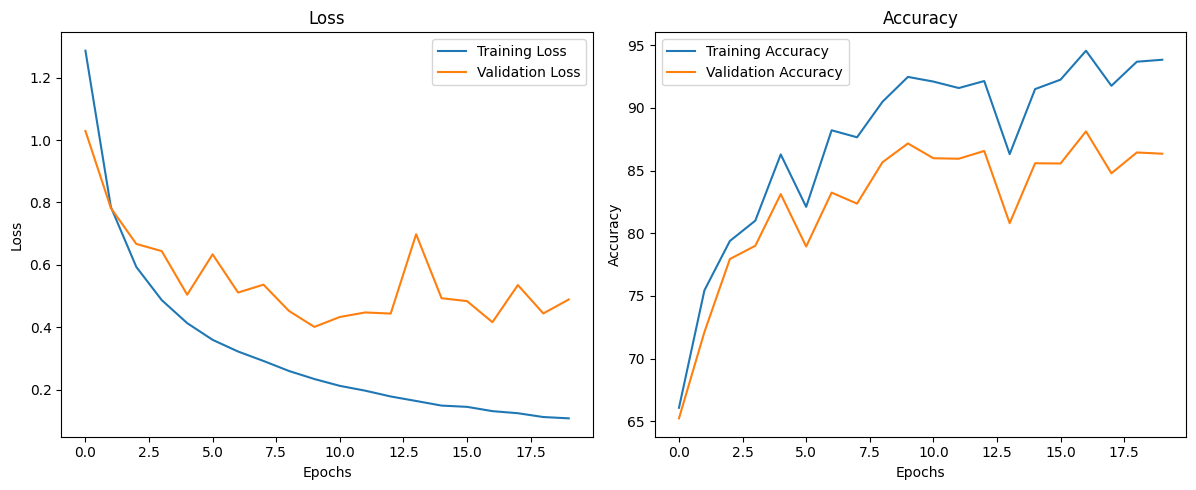

In [13]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show() 
    # plt.savefig() 

plot_history(history)

In [14]:
%watermark -iv

matplotlib : 3.7.2
numpy      : 1.26.4
pandas     : 2.2.3
sklearn    : 1.2.2
torch      : 2.6.0+cu124
torchinfo  : 1.8.0
torchvision: 0.21.0+cu124

